In [13]:
import pandas as pd
from prophet import Prophet
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [14]:
data = pd.read_csv('/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/Type of analysis/Analisis temporal/merged files/csv/microsoft/microsoft_data.csv')

#Reduce data for backtesting. Delete last 4 quarters

data = data.iloc[:-4]

In [15]:
# create column assets_liabilities_ratio
data['assets_liabilities_ratio'] = data['total_assets_musd'] / data['total_liabilities_musd']

# drop columns total_assets_musd total_liabilities_musd and other unnecessary columns
data = data.drop(columns=['total_assets_musd', 'total_liabilities_musd', 'Unnamed: 0'])

In [16]:
#1)rename date to ds and Price to y for prophet

data = data.rename(columns={"date": "ds", "Price": "y"})

data["ds"]= pd.to_datetime(data["ds"], format="%Y-%m-%d")

#reorder columns
data = data[["ds", "y", "revenue_musd", "net_income_musd", "assets_liabilities_ratio", "share_holder_equity_musd", "gdp_growth", "interest_rate"]]


data[40:]

,ds,y,revenue_musd,net_income_musd,assets_liabilities_ratio,share_holder_equity_musd,gdp_growth,interest_rate
40,2019-03-31,111.028870,30571.0,8809.0,1.563269,94864.0,1.93,2.42
41,2019-06-30,126.576942,33717.0,13187.0,1.555459,102330.0,2.24,2.40
42,2019-09-30,131.804962,33055.0,10678.0,1.613445,106061.0,2.80,1.83
43,2019-12-31,150.013428,36906.0,11649.0,1.637629,110109.0,3.35,1.55
44,2020-03-31,150.432755,35021.0,10752.0,1.669800,114501.0,1.28,0.05
45,2020-06-30,194.660019,38033.0,11202.0,1.646445,118304.0,-7.50,0.09
46,2020-09-30,201.669800,37154.0,13893.0,1.694740,123392.0,-1.41,0.09
47,2020-12-31,213.820297,43076.0,15463.0,1.748909,130236.0,-1.02,0.09
48,2021-03-31,227.176147,41706.0,15457.0,1.771359,134505.0,1.76,0.07
49,2021-06-30,261.628357,46152.0,16458.0,1.740327,141988.0,12.24,0.10


In [17]:
#2) Add a future base scenario so Proheet can make predictions

# ================== CONFIG ==================
FUTURE_PERIODS = 4    # nº de trimestres a predecir
FREQ = "Q"            # frecuencia trimestral
REG_COLS = ["revenue_musd", "net_income_musd", "assets_liabilities_ratio", "share_holder_equity_musd", "gdp_growth", "interest_rate"]

# ================== PREP ====================
df = data.copy()
#df = df.rename(columns={"DS": "ds"})   # Prophet requiere columnas: ds (datetime), y (target)
df["ds"] = pd.to_datetime(df["ds"], errors="coerce")

# Asegura que los regresores existan (si falta alguno, lo creamos como NaN)
for c in REG_COLS:
    if c not in df.columns:
        df[c] = np.nan

# Convierte gdp_growth a numérico si venía como texto/%
if df["gdp_growth"].dtype == "object":
    df["gdp_growth"] = (
        df["gdp_growth"].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        .replace({"": np.nan}).astype(float)
    )

# Rellena huecos internos con forward-fill (opcional pero útil para entrenar)
df[REG_COLS] = df[REG_COLS].ffill()

# ================== ESCENARIO FUTURO ==================
# Calcula crecimiento medio trimestral para flows/equity
growth_rates = {}
for col in ["revenue_musd", "net_income_musd", "share_holder_equity_musd"]:  #Calculate growth rates and append to dictionary
    growth_rates[col] = df[col].pct_change().mean(skipna=True)

growth_rates["gdp_growth"]=df["gdp_growth"].mean() #Cause gdp_growth is already a growth rate just calculate the mean
growth_rates["interest_rate"]=df["interest_rate"].mean() #Cause interest_rate is already a rate just calculate the mean


# Último punto observado
last = df.sort_values("ds").iloc[-1]

# Fechas futuras
future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]
future = pd.DataFrame({"ds": future_dates})

# Proyecta regresores (escenario baseline)
for col in ["revenue_musd", "net_income_musd", "share_holder_equity_musd"]:
    gr = 0.0 if np.isnan(growth_rates[col]) else growth_rates[col]
    future[col] = [last[col] * (1 + gr) ** i for i in range(1, FUTURE_PERIODS+1)]

# Mantén constantes estos regresores (o pon tu propio escenario)
future["assets_liabilities_ratio"] = last["assets_liabilities_ratio"]
# gdp_growth: mantener último valor (o define tu propio escenario macro)
future["gdp_growth"] = last["gdp_growth"]
# interest_rate: mantener último valor (o define tu propio escenario macro)
future["interest_rate"] = last["interest_rate"]

# Combina histórico (con y) y futuro (sin y)
hist = df[["ds", "y"] + REG_COLS].copy()
future_full = pd.concat([hist, future], ignore_index=True)

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_7556/3935995095.py:42: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]


In [18]:
#3) Initializa model and an train it

m=Prophet()

for col in REG_COLS:
    m.add_regressor(col)

#4) Fit and train with only historical data (with y)
train_df = future_full.dropna(subset=["y"]).copy()
m.fit(train_df)
                       

#5) Make predictions for the full dataset (historical + future)
predict_df = future_full[["ds"] + REG_COLS].copy()
forecast = m.predict(predict_df)

#6) Plot the results. Merge forecast with original data to compare
out = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    df[["ds","y"]], on="ds", how="left"
).sort_values("ds")

print(out.tail(12))


20:08:29 - cmdstanpy - INFO - Chain [1] start processing
20:08:29 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat  yhat_lower  yhat_upper           y
54 2022-09-30  263.751332  247.974132  279.767192  227.246918
55 2022-12-31  255.514294  238.367330  270.522521  234.658417
56 2023-03-31  282.241778  266.329933  296.806157  282.801575
57 2023-06-30  311.197451  294.805373  328.374442  334.775482
58 2023-09-30  328.130068  312.212526  344.875159  311.062347
59 2023-12-31  371.549322  354.899950  388.118396  371.209137
60 2024-03-31  405.205958  387.525921  422.685309  416.083160
61 2024-06-30  433.066776  416.365436  449.421591  442.821350
62 2024-09-30  465.956508  448.955422  484.117482         NaN
63 2024-12-31  463.551179  445.661425  479.485900         NaN
64 2025-03-31  505.368807  488.052428  522.565180         NaN
65 2025-06-30  514.253128  496.364177  531.077412         NaN


In [19]:
#7) Merge prediction with actual y

# Keep all rows (historical + future)
results = forecast[["ds","yhat","yhat_lower","yhat_upper"]].merge(
    data.rename(columns={"DS":"ds"})[["ds","y"]],
    on="ds", how="left"
)

# Flag which rows are future
results["is_future"] = results["y"].isna()

# Compute metrics only on historical rows
mask = ~results["is_future"]
mae = mean_absolute_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
rmse = mean_squared_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
r2   = r2_score(results.loc[mask,"y"], results.loc[mask,"yhat"])

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# Show last 12 rows (will include future with y = NaN)
print(results.tail(12))

MAE: 9.966442602968531
RMSE: 170.24197634866084
R²: 0.9873815066369503
           ds        yhat  yhat_lower  yhat_upper           y  is_future
54 2022-09-30  263.751332  247.974132  279.767192  227.246918      False
55 2022-12-31  255.514294  238.367330  270.522521  234.658417      False
56 2023-03-31  282.241778  266.329933  296.806157  282.801575      False
57 2023-06-30  311.197451  294.805373  328.374442  334.775482      False
58 2023-09-30  328.130068  312.212526  344.875159  311.062347      False
59 2023-12-31  371.549322  354.899950  388.118396  371.209137      False
60 2024-03-31  405.205958  387.525921  422.685309  416.083160      False
61 2024-06-30  433.066776  416.365436  449.421591  442.821350      False
62 2024-09-30  465.956508  448.955422  484.117482         NaN       True
63 2024-12-31  463.551179  445.661425  479.485900         NaN       True
64 2025-03-31  505.368807  488.052428  522.565180         NaN       True
65 2025-06-30  514.253128  496.364177  531.077412    

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_7556/327559522.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figl.show()


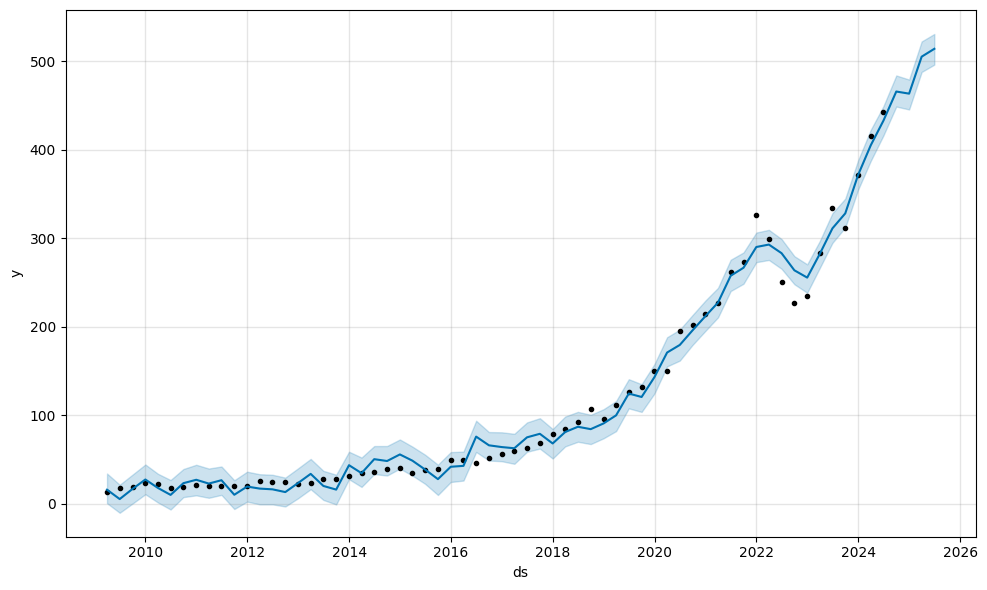

In [20]:
figl = m.plot(forecast)
figl.show()